In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

plt.style.use("seaborn-v0_8")


Load Data

In [2]:
ticker = "RELIANCE.NS"

df = yf.download(
    ticker,
    start="2015-01-01",
    end="2025-01-01"
)

df = df[['Close']].dropna()
df.head()


C:\Users\KRISHNENDU\AppData\Local\Temp\ipykernel_17268\3164813451.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,RELIANCE.NS
Date,
2015-01-01,189.999802
2015-01-02,189.496933
2015-01-05,187.421249
2015-01-06,178.915253
2015-01-07,182.809845


FEATURE ENGINEERING

In [3]:
for lag in [1, 2, 3, 5, 10]:
    df[f'lag_{lag}'] = df['Close'].shift(lag)

df.dropna(inplace=True)
df.head()


Price,Close,lag_1,lag_2,lag_3,lag_5,lag_10
Ticker,RELIANCE.NS,,,,,
Date,,,,,,
2015-01-15,184.938995,178.669174,180.423828,181.953873,180.188446,189.999802
2015-01-16,186.105240,184.938995,178.669174,180.423828,184.093735,189.496933
2015-01-19,188.234421,186.105240,184.938995,178.669174,181.953873,187.421249
2015-01-20,193.241714,188.234421,186.105240,184.938995,180.423828,178.915253
2015-01-21,194.033478,193.241714,188.234421,186.105240,178.669174,182.809845


Train–Test Split (Time-Based)

In [4]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train.drop(columns=['Close'])
y_train = train['Close']

X_test = test.drop(columns=['Close'])
y_test = test['Close']


Train Linear Regression Model

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Make Predictions

In [6]:
predictions = model.predict(X_test)


Evaluate Model

In [7]:
mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)


MAE: 12.035592187255181


Plot Predictions vs Actual

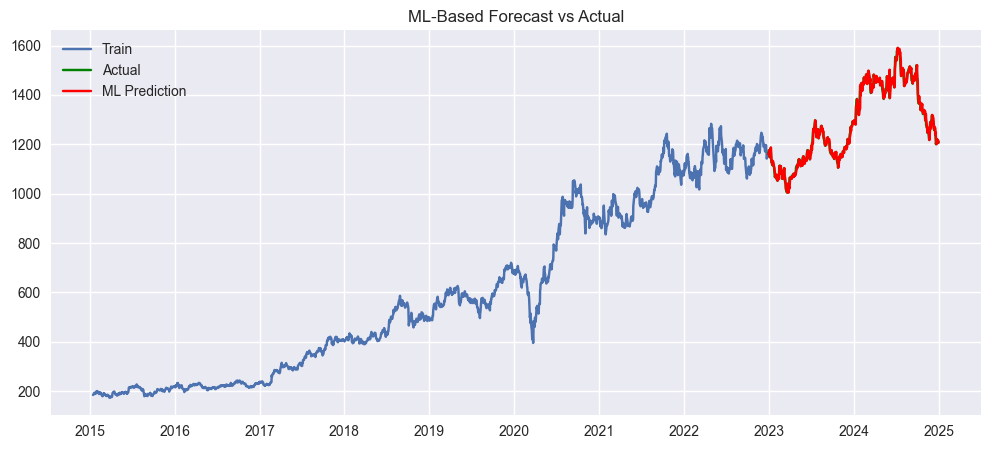

In [8]:
plt.figure(figsize=(12,5))
plt.plot(train['Close'], label='Train')
plt.plot(test.index, y_test, label='Actual', color='green')
plt.plot(test.index, predictions, label='ML Prediction', color='red')

plt.legend()
plt.title("ML-Based Forecast vs Actual")
plt.show()
